In [1]:
!pip install -q scikeras tensorflow scikit-learn

In [2]:
!pip install -U scikit-learn==1.5.2 scikeras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 72.4 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
hdbscan 0.8.44 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Shape: (60000, 28, 28)
Testing Shape : (10000, 28, 28)


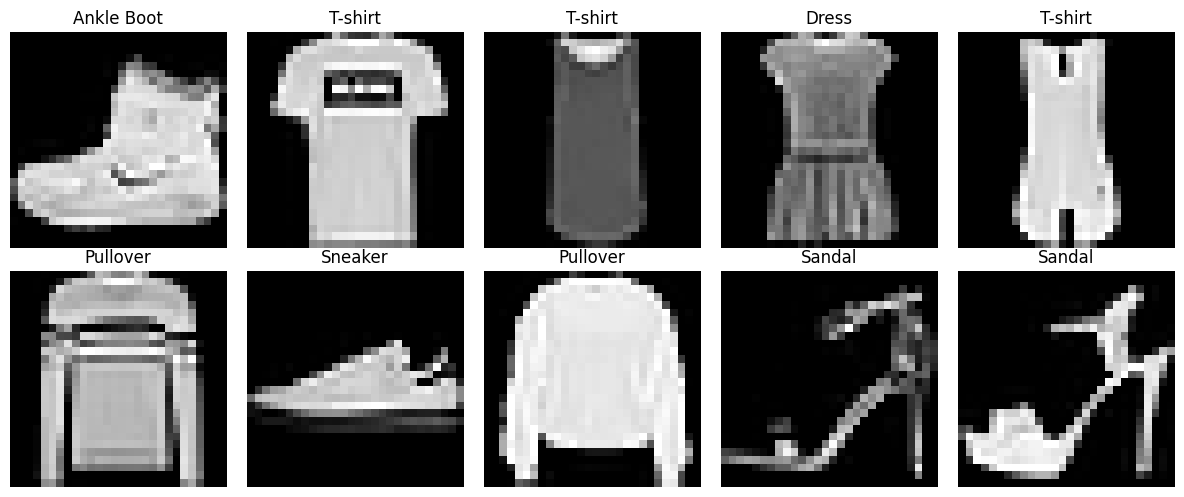

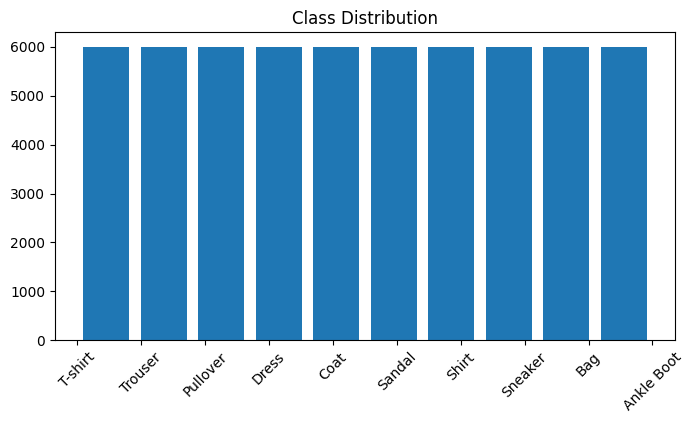

In [3]:
# Task 1 - Dataset Exploration

import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.datasets import fashion_mnist

(x_train,y_train),(x_test,y_test)=fashion_mnist.load_data()

print("Training Shape:",x_train.shape)
print("Testing Shape :",x_test.shape)

class_names=['T-shirt','Trouser','Pullover','Dress','Coat',
             'Sandal','Shirt','Sneaker','Bag','Ankle Boot']

plt.figure(figsize=(12,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i],cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
plt.hist(y_train,bins=10,rwidth=0.8)
plt.xticks(range(10),class_names,rotation=45)
plt.title("Class Distribution")
plt.show()


In [4]:
# Task 2 - Data Preprocessing

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical

# Load Dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Before Preprocessing
print("Before Preprocessing")
print("---------------------")
print("Training Images Shape :", x_train.shape)
print("Testing Images Shape  :", x_test.shape)
print("Training Labels Shape :", y_train.shape)
print("Testing Labels Shape  :", y_test.shape)

# Flatten Images
x_train = x_train.reshape(60000, 784).astype("float32")
x_test = x_test.reshape(10000, 784).astype("float32")

# Normalize Pixel Values
x_train = x_train / 255.0
x_test = x_test / 255.0

# One-Hot Encode Labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# After Preprocessing
print("\nAfter Preprocessing")
print("---------------------")
print("Training Images Shape :", x_train.shape)
print("Testing Images Shape  :", x_test.shape)
print("Training Labels Shape :", y_train.shape)
print("Testing Labels Shape  :", y_test.shape)


Before Preprocessing
---------------------
Training Images Shape : (60000, 28, 28)
Testing Images Shape  : (10000, 28, 28)
Training Labels Shape : (60000,)
Testing Labels Shape  : (10000,)

After Preprocessing
---------------------
Training Images Shape : (60000, 784)
Testing Images Shape  : (10000, 784)
Training Labels Shape : (60000, 10)
Testing Labels Shape  : (10000, 10)


In [5]:
# Task 3 - Model Construction

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input

model=Sequential([
Input(shape=(784,)),
Dense(128,activation='relu'),
Dense(64,activation='relu'),
Dense(10,activation='softmax')
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Task 4 - Model Training

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input

(x_train,y_train),(x_test,y_test)=fashion_mnist.load_data()

x_train=x_train.reshape(-1,784)/255.0
x_test=x_test.reshape(-1,784)/255.0

y_train=to_categorical(y_train,10)
y_test=to_categorical(y_test,10)

model=Sequential([
Input(shape=(784,)),
Dense(128,activation='relu'),
Dense(64,activation='relu'),
Dense(10,activation='softmax')
])

model.compile(optimizer='adam',
loss='categorical_crossentropy',
metrics=['accuracy'])

history=model.fit(x_train,y_train,
epochs=20,
batch_size=32,
validation_split=0.2)


Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8201 - loss: 0.5063 - val_accuracy: 0.8631 - val_loss: 0.3856
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8611 - loss: 0.3787 - val_accuracy: 0.8522 - val_loss: 0.3825
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8741 - loss: 0.3401 - val_accuracy: 0.8698 - val_loss: 0.3513
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8832 - loss: 0.3144 - val_accuracy: 0.8827 - val_loss: 0.3317
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8893 - loss: 0.2943 - val_accuracy: 0.8749 - val_loss: 0.3452
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8938 - loss: 0.2811 - val_accuracy: 0.8817 - val_loss: 0.3395
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8988 - loss: 0.2680 - val_accuracy: 0.8853 - val_loss: 0.3299
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9020 - loss: 0.2573 -

Accuracy : 0.8883
Precision: 0.8885062368340321
Recall   : 0.8883
F1 Score : 0.8882739858986133
              precision    recall  f1-score   support

           0       0.83      0.86      0.85      1000
           1       0.98      0.98      0.98      1000
           2       0.78      0.80      0.79      1000
           3       0.91      0.89      0.90      1000
           4       0.79      0.80      0.80      1000
           5       0.98      0.96      0.97      1000
           6       0.73      0.70      0.71      1000
           7       0.94      0.97      0.95      1000
           8       0.98      0.97      0.98      1000
           9       0.97      0.95      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



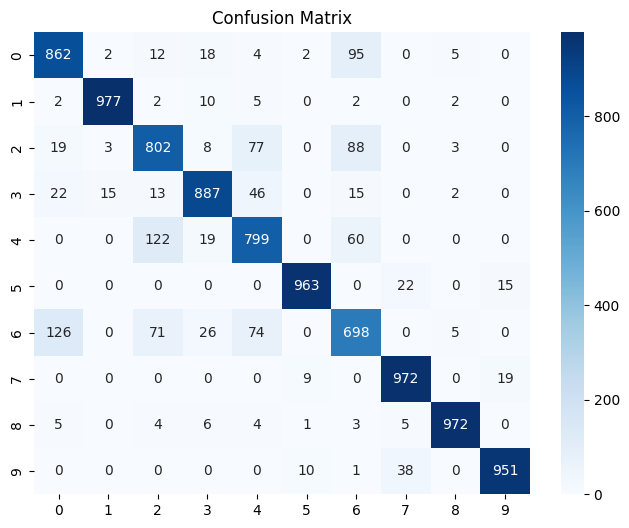

In [7]:
# Task 5 - Model Evaluation

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input

(x_train,y_train),(x_test,y_test)=fashion_mnist.load_data()

x_train=x_train.reshape(-1,784)/255.0
x_test=x_test.reshape(-1,784)/255.0

y_train_cat=to_categorical(y_train,10)

model=Sequential([
Input(shape=(784,)),
Dense(128,activation='relu'),
Dense(64,activation='relu'),
Dense(10,activation='softmax')
])

model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
model.fit(x_train,y_train_cat,epochs=20,batch_size=32,verbose=0)

pred=np.argmax(model.predict(x_test,verbose=0),axis=1)

print("Accuracy :",accuracy_score(y_test,pred))
print("Precision:",precision_score(y_test,pred,average='weighted'))
print("Recall   :",recall_score(y_test,pred,average='weighted'))
print("F1 Score :",f1_score(y_test,pred,average='weighted'))

print(classification_report(y_test,pred))

cm=confusion_matrix(y_test,pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


In [8]:
# Hyperparameter Task 1: Build Baseline MLP Model

import numpy as np
import tensorflow as tf

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.utils import to_categorical

# Load Dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Preprocess
x_train = x_train.reshape(-1, 784).astype("float32") / 255.0
x_test = x_test.reshape(-1, 784).astype("float32") / 255.0

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# Baseline Model
baseline_model = Sequential([
    Input(shape=(784,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

baseline_history = baseline_model.fit(
    x_train,
    y_train_cat,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

print("Baseline Model Completed.")

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8189 - loss: 0.5124 - val_accuracy: 0.8364 - val_loss: 0.4454
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8627 - loss: 0.3767 - val_accuracy: 0.8635 - val_loss: 0.3718
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8734 - loss: 0.3412 - val_accuracy: 0.8606 - val_loss: 0.3811
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8843 - loss: 0.3143 - val_accuracy: 0.8749 - val_loss: 0.3469
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8887 - loss: 0.2982 - val_accuracy: 0.8782 - val_loss: 0.3475
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8942 - loss: 0.2838 - val_accuracy: 0.8753 - val_loss: 0.3467
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8989 - loss: 0.2717 - val_accuracy: 0.8790 - val_loss: 0.3322
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9028 - loss: 0.2573 - 

In [9]:
# Hyperparameter Task 2 - Define Hyperparameter Search Space

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from scikeras.wrappers import KerasClassifier

# Function to build the model
def create_model(hidden_layers=2,
                 neurons=128,
                 learning_rate=0.001,
                 optimizer='adam',
                 activation='relu',
                 dropout=0.2):

    model = Sequential()

    model.add(Input(shape=(784,)))

    # Hidden Layers
    for _ in range(hidden_layers):
        model.add(Dense(neurons, activation=activation))
        if dropout > 0:
            model.add(Dropout(dropout))

    # Output Layer
    model.add(Dense(10, activation='softmax'))

    # Optimizer Selection
    if optimizer == 'adam':
        opt = Adam(learning_rate=learning_rate)

    elif optimizer == 'sgd':
        opt = SGD(learning_rate=learning_rate)

    else:
        opt = RMSprop(learning_rate=learning_rate)

    model.compile(
        optimizer=opt,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


# Wrap Keras model for Scikit-Learn
classifier = KerasClassifier(
    model=create_model,
    verbose=0
)

# Hyperparameter Search Space
param_grid = {
    "model__hidden_layers": [1, 2, 3],
    "model__neurons": [32, 64, 128, 256],
    "model__learning_rate": [0.1, 0.01, 0.001],
    "model__optimizer": ["sgd", "adam", "rmsprop"],
    "model__activation": ["relu", "tanh", "sigmoid"],
    "model__dropout": [0.0, 0.2, 0.5],
    "batch_size": [16, 32, 64, 128],
    "epochs": [10, 20, 30]
}

print("Hyperparameter Search Space defined.")

for key, value in param_grid.items():
    print(f"{key}: {value}")

Hyperparameter Search Space defined.
model__hidden_layers: [1, 2, 3]
model__neurons: [32, 64, 128, 256]
model__learning_rate: [0.1, 0.01, 0.001]
model__optimizer: ['sgd', 'adam', 'rmsprop']
model__activation: ['relu', 'tanh', 'sigmoid']
model__dropout: [0.0, 0.2, 0.5]
batch_size: [16, 32, 64, 128]
epochs: [10, 20, 30]


In [10]:
# Hyperparameter Task 3 - Perform RandomizedSearchCV

from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    estimator=classifier,
    param_distributions=param_grid,
    n_iter=5,
    cv=5,
    scoring="accuracy",
    random_state=42,
    verbose=2,
    n_jobs=1
)

print("Starting Hyperparameter Search...\n")

random_search.fit(x_train, y_train_cat)

print("\nHyperparameter Search Completed Successfully!")

Starting Hyperparameter Search...

Fitting 5 folds for each of 5 candidates, totalling 25 fits
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout=0.2, model__hidden_layers=1, model__learning_rate=0.001, model__neurons=256, model__optimizer=adam; total time= 1.3min
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout=0.2, model__hidden_layers=1, model__learning_rate=0.001, model__neurons=256, model__optimizer=adam; total time= 1.4min
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout=0.2, model__hidden_layers=1, model__learning_rate=0.001, model__neurons=256, model__optimizer=adam; total time= 1.4min
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout=0.2, model__hidden_layers=1, model__learning_rate=0.001, model__neurons=256, model__optimizer=adam; total time= 1.3min
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout=0.2, model__hidden_layers=1, model__learning_rate=0.001, mo

In [11]:
# Hyperparameter Task 4 - Record Best Hyperparameters

print("Best Hyperparameters:\n")
print(random_search.best_params_)

print("\nBest Cross Validation Accuracy:")
print(random_search.best_score_)

Best Hyperparameters:

{'model__optimizer': 'adam', 'model__neurons': 256, 'model__learning_rate': 0.001, 'model__hidden_layers': 1, 'model__dropout': 0.2, 'model__activation': 'tanh', 'epochs': 20, 'batch_size': 64}

Best Cross Validation Accuracy:
0.8908333333333334


In [12]:
# Hyperparameter Task 5 - Retrain the Model Using Best Hyperparameters

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

# Retrieve the best parameters
best_params = random_search.best_params_

# Select optimizer
if best_params["model__optimizer"] == "adam":
    optimizer = Adam(learning_rate=best_params["model__learning_rate"])
elif best_params["model__optimizer"] == "sgd":
    optimizer = SGD(learning_rate=best_params["model__learning_rate"])
else:
    optimizer = RMSprop(learning_rate=best_params["model__learning_rate"])

# Build optimized model
optimized_model = Sequential()

optimized_model.add(Input(shape=(784,)))

for i in range(best_params["model__hidden_layers"]):
    optimized_model.add(
        Dense(best_params["model__neurons"],
              activation=best_params["model__activation"])
    )

    if best_params["model__dropout"] > 0:
        optimized_model.add(
            Dropout(best_params["model__dropout"])
        )

optimized_model.add(Dense(10, activation="softmax"))

optimized_model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Train optimized model
optimized_history = optimized_model.fit(
    x_train,
    y_train_cat,
    epochs=best_params["epochs"],
    batch_size=best_params["batch_size"],
    validation_split=0.2,
    verbose=1
)

print("\nOptimized Model Trained Successfully!")

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8088 - loss: 0.5406 - val_accuracy: 0.8447 - val_loss: 0.4256
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8472 - loss: 0.4280 - val_accuracy: 0.8583 - val_loss: 0.3964
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8593 - loss: 0.3895 - val_accuracy: 0.8664 - val_loss: 0.3736
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8659 - loss: 0.3692 - val_accuracy: 0.8707 - val_loss: 0.3572
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8699 - loss: 0.3530 - val_accuracy: 0.8684 - val_loss: 0.3614
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8751 - loss: 0.3369 - val_accuracy: 0.8639 - val_loss: 0.3731
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8784 - loss: 0.3282 - val_accuracy: 0.8718 - val_loss: 0.3505
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8823 - loss: 0.3182 - val_accuracy: 0.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Optimized Model Performance
----------------------------
Accuracy : 0.8794
Precision: 0.8801999017505483
Recall   : 0.8794
F1 Score : 0.8773842154256565

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.84      0.84      1000
           1       0.99      0.96      0.98      1000
           2       0.78      0.80      0.79      1000
           3       0.86      0.92      0.89      1000
           4       0.74      0.87      0.80      1000
           5       0.98      0.94      0.96      1000
           6       0.79      0.57      0.66      1000
           7       0.92      0.97      0.94      1000
           8       0.96      0.98      0.97      1000
           9       0.95      0.95      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



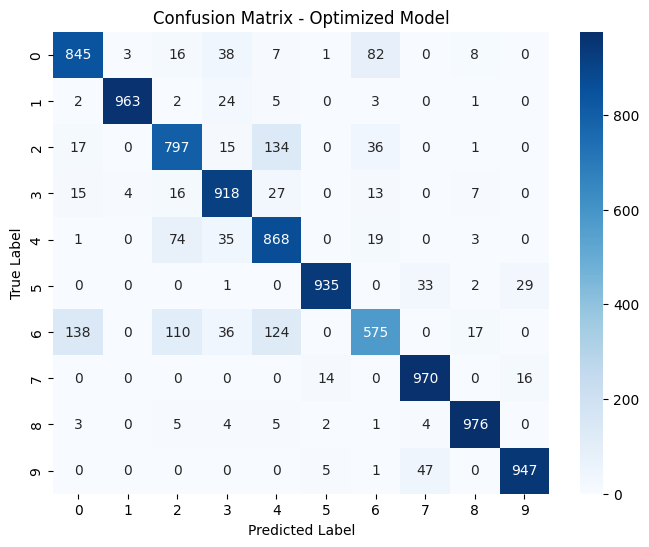

In [13]:
# Hyperparameter Task 6 - Evaluate the Optimized Model

import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict on test data
y_pred_prob = optimized_model.predict(x_test)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_prob, axis=1)

# Convert one-hot encoded labels back to integers
y_true = np.argmax(y_test_cat, axis=1)

# Evaluation Metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("Optimized Model Performance")
print("----------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nClassification Report")
print(classification_report(y_true, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Optimized Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

Model Comparison
----------------------------
Baseline Model Accuracy : 0.8829
Optimized Model Accuracy: 0.8794


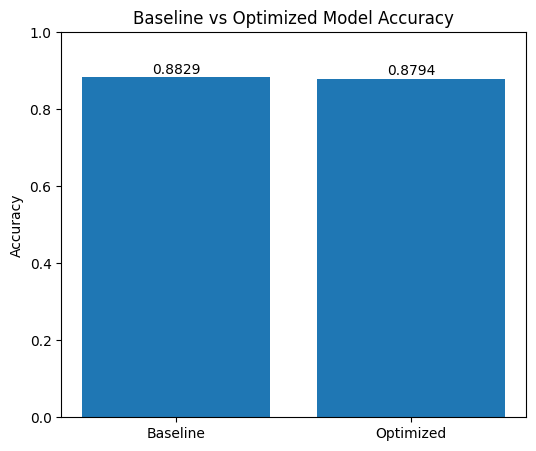

In [14]:
# Hyperparameter Task 7 - Compare Baseline and Optimized Models

# Baseline Model Accuracy
baseline_loss, baseline_accuracy = baseline_model.evaluate(
    x_test,
    y_test_cat,
    verbose=0
)

# Optimized Model Accuracy
optimized_loss, optimized_accuracy = optimized_model.evaluate(
    x_test,
    y_test_cat,
    verbose=0
)

print("Model Comparison")
print("----------------------------")
print(f"Baseline Model Accuracy : {baseline_accuracy:.4f}")
print(f"Optimized Model Accuracy: {optimized_accuracy:.4f}")

# Bar Chart
plt.figure(figsize=(6,5))

models = ["Baseline", "Optimized"]
accuracies = [baseline_accuracy, optimized_accuracy]

plt.bar(models, accuracies)

plt.title("Baseline vs Optimized Model Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

for i, value in enumerate(accuracies):
    plt.text(i, value + 0.01, f"{value:.4f}", ha='center')

plt.show()

Mandatory Plots

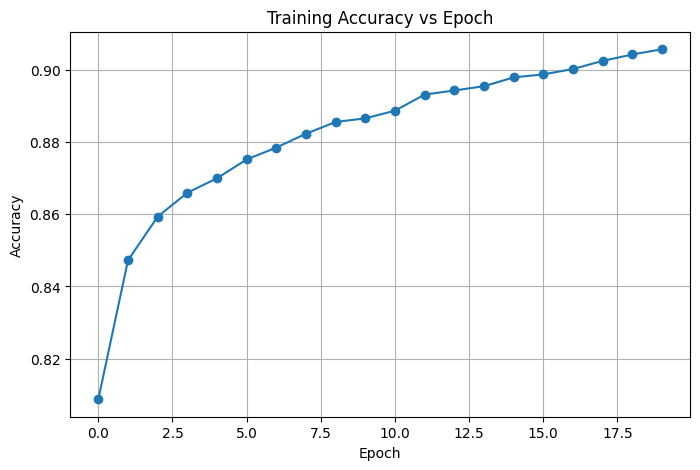

In [15]:
# Plot 3 - Training Accuracy vs Epoch

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(optimized_history.history['accuracy'], marker='o')

plt.title("Training Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)

plt.show()

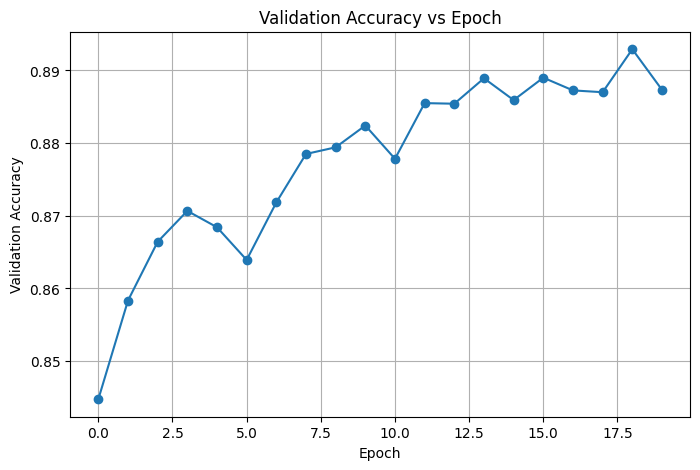

In [16]:
# Plot 4 - Validation Accuracy vs Epoch

plt.figure(figsize=(8,5))
plt.plot(optimized_history.history['val_accuracy'], marker='o')

plt.title("Validation Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.grid(True)

plt.show()

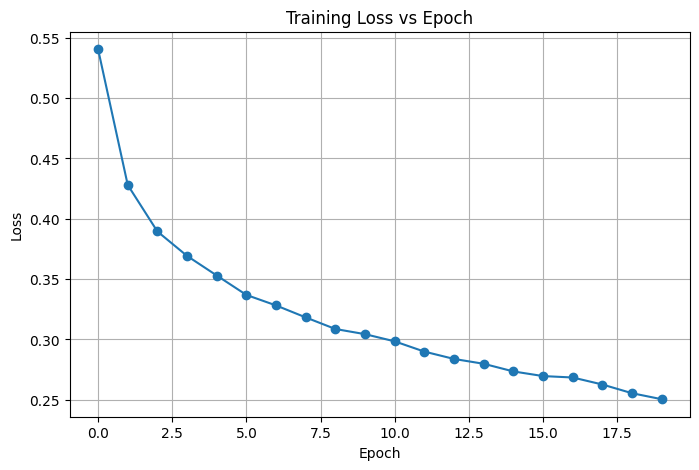

In [17]:
# Plot 5 - Training Loss vs Epoch

plt.figure(figsize=(8,5))
plt.plot(optimized_history.history['loss'], marker='o')

plt.title("Training Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.show()

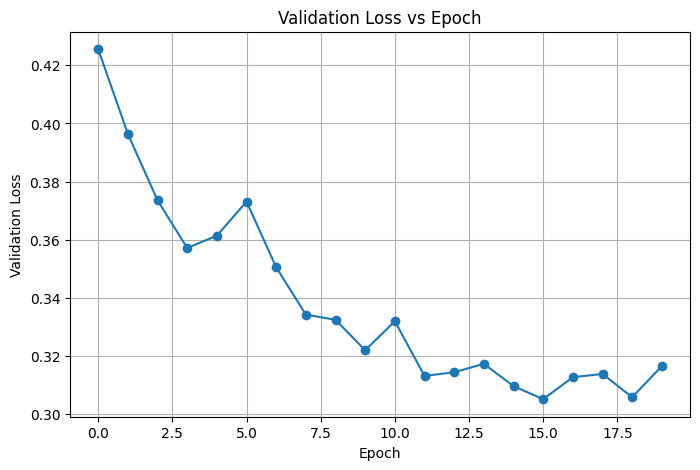

In [18]:
# Plot 6 - Validation Loss vs Epoch

plt.figure(figsize=(8,5))
plt.plot(optimized_history.history['val_loss'], marker='o')

plt.title("Validation Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.grid(True)

plt.show()

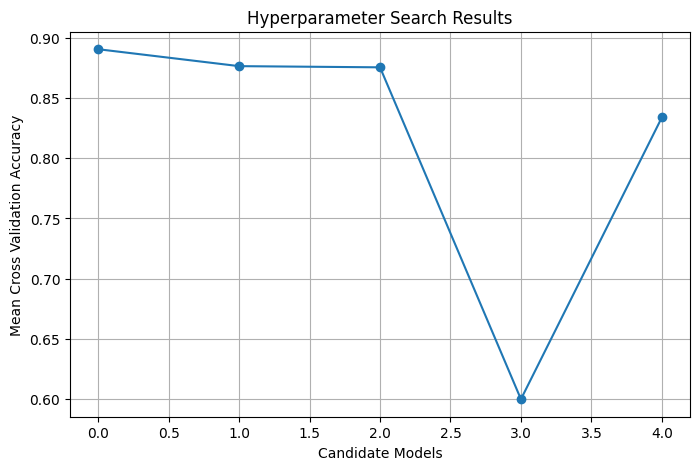

In [19]:
# Plot 8 - Hyperparameter Search Results

import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame(random_search.cv_results_)

plt.figure(figsize=(8,5))
plt.plot(results["mean_test_score"], marker='o')

plt.title("Hyperparameter Search Results")
plt.xlabel("Candidate Models")
plt.ylabel("Mean Cross Validation Accuracy")
plt.grid(True)

plt.show()